# Comparación de matrices · TFM Energía UCM

Hace dos cosas: **ejecuta** la rejilla de entrenamientos (sección 0) y **analiza** el
resultado (secciones 1 a 5). Las dos partes son independientes, así que la rejilla se puede
lanzar por terminal y usar este notebook solo para mirar.

El puente entre ambas es `data/gold/rejilla_matrices.csv`, que se escribe después de **cada**
entrenamiento. Por eso el análisis funciona con la rejilla a medias: refresca la primera
celda de la sección 1 y muestra lo que haya.

## La pregunta

Las cuatro matrices existen para contestar tres cosas:

| comparación | pregunta |
|---|---|
| `completa` vs `nucleo` | ¿sobran variables? |
| `minima` vs `nucleo` | ¿bastan las 25 mejores? |
| `moderna` vs `nucleo` | ¿estorba la crisis del gas de 2020-2022? |

Y tres arquitecturas que cubren el espectro de tamaños —SimpleRNN ~35 k, GRU ~320 k,
Conv1D+LSTM ~460 k— porque el tamaño de la matriz interactúa con el del modelo: con menos
datos, los modelos pequeños suben posiciones.

## 0 · Ejecutar la rejilla

Se puede lanzar desde aquí en vez de por terminal. Reutiliza las funciones de
`scripts/rejilla_matrices.py` — no hay código duplicado, así que si el script cambia, esto
cambia con él.

**Cada entrenamiento escribe en el CSV.** Puedes parar la celda cuando quieras, y al volver
a ejecutarla continúa donde estaba: salta lo que ya esté en el fichero. Y las secciones de
análisis, más abajo, funcionan con resultados parciales.

**El orden importa para la espera.** Por defecto empieza por `minima`, que tiene 10 canales
de encoder en vez de 60: el primer resultado llega en un par de minutos y confirmas que
todo funciona antes de comprometer una hora. `completa` va la última porque construir sus
paneles ya lleva su rato.

| | |
|---|---|
| `MATRICES` | cuáles y en qué orden |
| `ARQUITECTURAS` | las tres cubren de 35 k a 460 k parámetros |
| `SEMILLAS` | 3 para poder distinguir señal de ruido; 1 para una pasada rápida |

Si prefieres lanzarlo por terminal y dejarlo desatendido, es lo mismo:

```bash
python scripts/rejilla_matrices.py
```

In [1]:
import sys, time
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "gold").is_dir())
sys.path.append(str(REPO / "scripts"))

MATRICES      = ["minima", "nucleo", "moderna", "completa"]   # la ligera primero
ARQUITECTURAS = ["SimpleRNN", "GRU", "Conv1D+LSTM"]
SEMILLAS      = 3

EJECUTAR = True        # <- ponlo a True y ejecuta esta celda para entrenar

In [2]:
if not EJECUTAR:
    print("EJECUTAR = False. Cambia a True en la celda anterior para lanzar la rejilla.")
    print("Si ya la lanzaste por terminal, salta a la seccion 1: lee el mismo CSV.")
else:
    import numpy as np, pandas as pd
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from preparar_tensores import preparar, residuo
    from rejilla_matrices import metricas, construir, SALIDA, SEMILLA, EPOCHS, BATCH

    print("GPU:", bool(tf.config.list_physical_devices("GPU")))
    hechos = pd.read_csv(SALIDA).to_dict("records") if SALIDA.exists() else []
    yahay = {(r["matriz"], r["arquitectura"], r["semilla"]) for r in hechos}
    total = len(MATRICES) * len(ARQUITECTURAS) * SEMILLAS
    print(f"{len(hechos)} de {total} ya hechos; faltan {total - len(hechos)}")
    print()

    t0 = time.time()
    for matriz in MATRICES:
        T = preparar(matriz)
        yr, inv_r, _, _ = residuo(T)
        nv = float(metricas(T.y[T.va], T.naive[T.va])["MAE"])
        print(f"   naive val {nv:.2f}")
        for arq in ARQUITECTURAS:
            for s in range(SEMILLAS):
                if (matriz, arq, SEMILLA + s) in yahay:
                    continue
                keras.utils.set_random_seed(SEMILLA + s)
                m = construir(arq, T, keras, layers)
                m.fit(T.ent(T.tr), yr[T.tr],
                      validation_data=(T.ent(T.va), yr[T.va]),
                      epochs=EPOCHS, batch_size=BATCH, verbose=0,
                      callbacks=[keras.callbacks.EarlyStopping(
                                     monitor="val_loss", patience=12,
                                     restore_best_weights=True),
                                 keras.callbacks.ReduceLROnPlateau(
                                     monitor="val_loss", factor=0.5, patience=5,
                                     min_lr=1e-5)])
                mv = metricas(T.y[T.va], inv_r(m.predict(T.ent(T.va), verbose=0), T.va))
                mt = metricas(T.y[T.te], inv_r(m.predict(T.ent(T.te), verbose=0), T.te))
                hechos.append({
                    "matriz": matriz, "hash": T.meta.get("hash", "?"),
                    "arquitectura": arq, "semilla": SEMILLA + s,
                    "parametros": int(m.count_params()),
                    "dias_train": int(T.tr.sum()), "canales": T.X_enc.shape[-1],
                    "MAE_val": round(mv["MAE"], 3), "MAE_test": round(mt["MAE"], 3),
                    "captura_val_%": round(mv["captura_%"], 2),
                    "vs_naive_val_%": round(100 * (mv["MAE"] / nv - 1), 1),
                    "naive_val": round(nv, 3)})
                pd.DataFrame(hechos).to_csv(SALIDA, index=False)
                r = hechos[-1]
                print(f"   {arq:12s} s{s}  MAE val {r['MAE_val']:6.3f} "
                      f"({r['vs_naive_val_%']:+5.1f}%) · test {r['MAE_test']:6.3f}"
                      f"   [{(time.time()-t0)/60:.0f} min]")
        print()
    print(f"Listo. {len(hechos)} entrenamientos en {SALIDA.name}.")
    print("Ejecuta la seccion 1 en adelante para el analisis.")

GPU: False
3 de 36 ya hechos; faltan 33

minima    hash 850d4726 · 2,389 dias · encoder 12 canales · decoder 7 · estaticos 13 · train 1812 val 365 test 212
   naive val 19.95
   GRU          s0  MAE val 16.843 (-15.6%) · test 16.701   [2 min]
   GRU          s1  MAE val 16.859 (-15.5%) · test 16.001   [5 min]
   GRU          s2  MAE val 16.626 (-16.7%) · test 16.136   [7 min]
   Conv1D+LSTM  s0  MAE val 18.556 ( -7.0%) · test 17.899   [8 min]
   Conv1D+LSTM  s1  MAE val 18.918 ( -5.2%) · test 17.371   [8 min]
   Conv1D+LSTM  s2  MAE val 18.221 ( -8.7%) · test 17.375   [8 min]

nucleo    hash 35bf390e · 2,389 dias · encoder 57 canales · decoder 21 · estaticos 26 · train 1812 val 365 test 212
   naive val 19.95
   SimpleRNN    s0  MAE val 15.333 (-23.1%) · test 13.862   [9 min]
   SimpleRNN    s1  MAE val 15.318 (-23.2%) · test 14.981   [10 min]
   SimpleRNN    s2  MAE val 15.230 (-23.7%) · test 13.792   [10 min]
   GRU          s0  MAE val 14.106 (-29.3%) · test 13.491   [11 min]
   GRU

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.width", 200)

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "gold").is_dir())
CSV = REPO / "data" / "gold" / "rejilla_matrices.csv"

# El script escribe el CSV despues de CADA entrenamiento, asi que si el fichero no existe
# es que ni el primero ha terminado. No es un error: es que hay que esperar.
if not CSV.exists():
    print(f"Todavia no hay resultados: {CSV} no existe.")
    print()
    print("El script escribe tras cada entrenamiento, asi que el fichero aparece en cuanto")
    print("acabe el primero. Si tarda, es normal: el primero paga la compilacion JIT y")
    print("`completa` es la matriz mas grande -- construir sus paneles ya lleva un par de")
    print("minutos antes de empezar a entrenar.")
    print()
    print("Mira la terminal donde lo lanzaste. Deberias ver la cabecera y luego una linea")
    print("por entrenamiento. Cuando aparezca la primera, vuelve a ejecutar esta celda.")
    d = None
else:
    d = pd.read_csv(CSV)
    esperado = d.matriz.nunique() * d.arquitectura.nunique() * d.semilla.nunique()
    print(f"{len(d)} entrenamientos de {esperado} previstos "
          f"({len(d) / max(esperado, 1) * 100:.0f}%)")
    print(f"matrices      : {sorted(d.matriz.unique())}")
    print(f"arquitecturas : {sorted(d.arquitectura.unique())}")
    print(f"semillas      : {sorted(d.semilla.unique())}")
    if len(d) < esperado:
        print()
        print("La rejilla sigue corriendo. Vuelve a ejecutar esta celda para refrescar.")

HAY = d is not None and len(d) > 0

36 entrenamientos de 36 previstos (100%)
matrices      : ['completa', 'minima', 'moderna', 'nucleo']
arquitecturas : ['Conv1D+LSTM', 'GRU', 'SimpleRNN']
semillas      : [np.int64(42), np.int64(43), np.int64(44)]


## 1 · Media y desviación por celda

El MAE de validación es comparable entre columnas porque **las cuatro matrices validan
sobre el mismo periodo**, 2025 entero. Lo que cambia es con cuántos días entrena cada una.

mean                              std                      
matriz       completa  minima moderna  nucleo completa minima moderna nucleo
arquitectura                                                                
Conv1D+LSTM    15.549  18.565  16.106  14.803    0.587  0.349   0.833  0.053
GRU            17.733  16.776  16.522  14.155    0.142  0.130   1.009  0.125
SimpleRNN      17.723  18.133  16.898  15.294    0.703  0.261   0.826  0.056

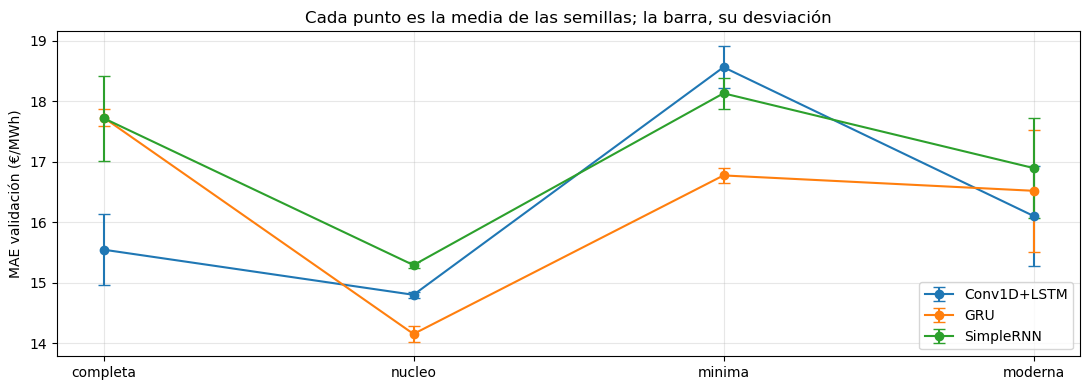

Si las barras de dos matrices se solapan, esa diferencia NO es concluyente
con medias sueltas. Para eso está la comparación pareada de la sección 2.


In [4]:
if not HAY:
    print("Sin datos todavia. Ejecuta la primera celda cuando la rejilla haya avanzado.")
else:
    piv = d.pivot_table(index="arquitectura", columns="matriz", values="MAE_val",
                        aggfunc=["mean", "std"]).round(3)
    display(piv)

    if d.semilla.nunique() > 1:
        fig, ax = plt.subplots(figsize=(11, 4))
        for arq, g in d.groupby("arquitectura"):
            r = g.groupby("matriz")["MAE_val"].agg(["mean", "std"]).reindex(
                [m for m in ["completa", "nucleo", "minima", "moderna"] if m in set(d.matriz)])
            ax.errorbar(r.index, r["mean"], yerr=r["std"], marker="o", capsize=4, label=arq)
        ax.set_ylabel("MAE validación (€/MWh)")
        ax.set_title("Cada punto es la media de las semillas; la barra, su desviación")
        ax.legend(); ax.grid(alpha=.3)
        plt.tight_layout(); plt.show()
        print("Si las barras de dos matrices se solapan, esa diferencia NO es concluyente")
        print("con medias sueltas. Para eso está la comparación pareada de la sección 2.")

## 2 · Comparación pareada — la que decide

Comparar medias sueltas desperdicia el diseño. Las cuatro matrices se entrenan con **las
mismas semillas**, así que restando cada matriz contra `nucleo` en la **misma semilla y
arquitectura** desaparece la varianza de inicialización, que es la que ensucia todo.

Con medias sueltas hacen falta diferencias de ~0,5 para distinguir algo; pareado basta con
~0,15. Y el criterio se lee sin estadística: **si las diferencias tienen todas el mismo
signo y superan su propia dispersión, hay ganador; si cambian de signo, es ruido.**

In [5]:
if not HAY:
    print("Sin datos todavia. Ejecuta la primera celda cuando la rejilla haya avanzado.")
else:
    REF = "nucleo"
    base = d[d.matriz == REF].set_index(["arquitectura", "semilla"])["MAE_val"]

    filas = []
    for m in [x for x in d.matriz.unique() if x != REF]:
        otra = d[d.matriz == m].set_index(["arquitectura", "semilla"])["MAE_val"]
        dif = (otra - base).dropna()
        if not len(dif):
            continue
        mismo = bool((dif > 0).all() or (dif < 0).all())
        filas.append({"matriz": m, "n_pares": len(dif),
                      "dif_media": round(float(dif.mean()), 3),
                      "dif_sd": round(float(dif.std(ddof=1)), 3) if len(dif) > 1 else np.nan,
                      "mismo_signo": mismo,
                      "veredicto": (f"gana {REF}" if dif.mean() > 0 else f"gana {m}")
                                   if mismo and abs(dif.mean()) > 0.15 else "empate"})

    if filas:
        pareada = pd.DataFrame(filas)
        display(pareada)
        print(f"`dif_media` positiva = esa matriz es PEOR que {REF}.")
        print()
        for r in pareada.itertuples():
            if r.veredicto == "empate":
                if r.matriz == "moderna":
                    print(f"· {r.matriz}: EMPATE, y es un hallazgo -- consigue lo mismo con el")
                    print(f"  40 % de los días. 2020-2022 no aportan.")
                elif r.matriz == "completa":
                    print(f"· {r.matriz}: empate -> gana `nucleo`, mismo resultado con 113")
                    print(f"  inputs en vez de 141.")
                else:
                    print(f"· {r.matriz}: empate.")
            else:
                print(f"· {r.matriz}: {r.veredicto} por {abs(r.dif_media):.3f}, "
                      f"consistente en las {r.n_pares} comparaciones.")

,matriz,n_pares,dif_media,dif_sd,mismo_signo,veredicto
0,minima,9,3.074,0.563,True,gana nucleo
1,moderna,9,1.758,0.882,True,gana nucleo
2,completa,9,2.251,1.319,True,gana nucleo


`dif_media` positiva = esa matriz es PEOR que nucleo.

· minima: gana nucleo por 3.074, consistente en las 9 comparaciones.
· moderna: gana nucleo por 1.758, consistente en las 9 comparaciones.
· completa: gana nucleo por 2.251, consistente en las 9 comparaciones.


In [6]:
if not HAY:
    print("Sin datos todavia. Ejecuta la primera celda cuando la rejilla haya avanzado.")
else:
    REF = "nucleo"          # definido aqui tambien: esta celda no depende de la anterior
    # El detalle por semilla, que es donde se ve si el signo aguanta
    if len(d.semilla.unique()) > 1:
        det = (d.pivot_table(index=["arquitectura", "semilla"], columns="matriz",
                             values="MAE_val")
                 .pipe(lambda x: x.sub(x[REF], axis=0))
                 .drop(columns=[REF]).round(3))
        display(det)
        print("Cada fila es una comparación pareada. Columnas todas del mismo signo = señal;")
        print("columnas que cambian de signo = ruido de inicialización.")

matriz                completa  minima  moderna
arquitectura semilla                           
Conv1D+LSTM  42          1.294   3.756    0.502
             43          0.070   4.061    2.108
             44          0.875   3.470    1.301
GRU          42          3.625   2.737    3.348
             43          3.579   2.562    2.364
             44          3.530   2.563    1.388
SimpleRNN    42          3.112   2.573    1.672
             43          1.723   3.100    2.348
             44          2.452   2.846    0.794

Cada fila es una comparación pareada. Columnas todas del mismo signo = señal;
columnas que cambian de signo = ruido de inicialización.


## 3 · Qué arquitectura gana en cada matriz

Aquí está la razón de usar tres tamaños en vez de la mejor de `nucleo`: si el orden cambia
entre columnas, el tamaño de la matriz interactúa con el del modelo, y elegir arquitectura
mirando una sola matriz habría sesgado el resultado.

In [7]:
if not HAY:
    print("Sin datos todavia. Ejecuta la primera celda cuando la rejilla haya avanzado.")
else:
    orden = (d.groupby(["matriz", "arquitectura"])["MAE_val"].mean()
               .groupby("matriz").rank().unstack().round(1))
    display(orden)

    # `orden` tiene las matrices en filas y las arquitecturas en columnas, asi que la
    # pregunta -- ¿cambia el orden ENTRE matrices? -- se responde mirando cada columna
    # hacia abajo. Por filas siempre saldrian 3 rangos distintos y la condicion seria
    # verdadera siempre.
    cambia = bool(orden.nunique(axis=0).gt(1).any()) if len(orden) > 1 else False
    if cambia:
        print("EL ORDEN CAMBIA entre matrices: el tamaño del modelo interactúa con el de la")
        print("matriz, y hay que elegir arquitectura DESPUÉS de elegir matriz.")
    else:
        print("El orden se mantiene en todas: la arquitectura se puede elegir con independencia")
        print("de la matriz, lo que simplifica la decisión.")

    print()
    print("Y contra la persistencia, que es el listón real:")
    display(d.pivot_table(index="arquitectura", columns="matriz",
                          values="vs_naive_val_%", aggfunc="mean").round(1))

arquitectura,Conv1D+LSTM,GRU,SimpleRNN
matriz,,,
completa,1.0,3.0,2.0
minima,3.0,1.0,2.0
moderna,1.0,2.0,3.0
nucleo,2.0,1.0,3.0


EL ORDEN CAMBIA entre matrices: el tamaño del modelo interactúa con el de la
matriz, y hay que elegir arquitectura DESPUÉS de elegir matriz.

Y contra la persistencia, que es el listón real:


matriz,completa,minima,moderna,nucleo
arquitectura,,,,
Conv1D+LSTM,-22.1,-7.0,-19.3,-25.8
GRU,-11.1,-15.9,-17.2,-29.0
SimpleRNN,-11.2,-9.1,-15.3,-23.3


## 4 · Coste en datos

`moderna` entrena con el 40 % de las filas. Si empata, no está empatando: está ganando en
eficiencia, y eso significa que los años de la crisis del gas no aportan información
utilizable.

,dias_train,canales,MAE_val
matriz,,,
completa,1812,66,17.002
minima,1812,12,17.825
nucleo,1812,57,14.751
moderna,723,57,16.509


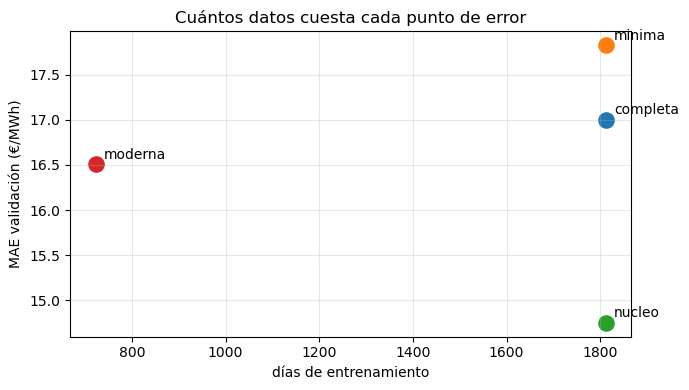

In [8]:
if not HAY:
    print("Sin datos todavia. Ejecuta la primera celda cuando la rejilla haya avanzado.")
else:
    cst = (d.groupby("matriz")
             .agg(dias_train=("dias_train", "first"), canales=("canales", "first"),
                  MAE_val=("MAE_val", "mean"))
             .sort_values("dias_train", ascending=False).round(3))
    display(cst[["dias_train", "canales", "MAE_val"]])

    fig, ax = plt.subplots(figsize=(7, 4))
    for m, r in cst.iterrows():
        ax.scatter(r.dias_train, r.MAE_val, s=120)
        ax.annotate(m, (r.dias_train, r.MAE_val), xytext=(6, 4), textcoords="offset points")
    ax.set_xlabel("días de entrenamiento"); ax.set_ylabel("MAE validación (€/MWh)")
    ax.set_title("Cuántos datos cuesta cada punto de error")
    ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 5 · La decisión

Y el comando de la fase B con la matriz elegida.

In [9]:
if not HAY:
    print("Sin datos todavia. Ejecuta la primera celda cuando la rejilla haya avanzado.")
else:
    ganadora = d.groupby("matriz")["MAE_val"].mean().idxmin()
    media = d.groupby("matriz")["MAE_val"].mean().round(3)

    print("MAE de validación medio por matriz:")
    print(media.sort_values().to_string())
    print()
    print(f"Mejor media: {ganadora}")
    print()
    print("PERO la media no decide: mira la sección 2. Si `nucleo` empata con la que tenga")
    print("mejor media, gana `nucleo` por ser la referencia ya probada y auditada -- cambiar")
    print("de matriz obliga a rehacer todo lo que cuelga de ella.")
    print()
    print("Cuando lo tengas claro, la fase B:")
    print()
    print(f"    python scripts/entrenar_finales.py --matriz {ganadora} "
          f"--semillas 3 --guardar-modelos")
    print()
    print("8 familias x 3 semillas = 24 entrenamientos, ~1,5 h. Deja los .keras con su")
    print(".preprocesado.json, las predicciones de validación y el ensemble por familia.")

MAE de validación medio por matriz:
matriz
nucleo      14.751
moderna     16.509
completa    17.002
minima      17.825

Mejor media: nucleo

PERO la media no decide: mira la sección 2. Si `nucleo` empata con la que tenga
mejor media, gana `nucleo` por ser la referencia ya probada y auditada -- cambiar
de matriz obliga a rehacer todo lo que cuelga de ella.

Cuando lo tengas claro, la fase B:

    python scripts/entrenar_finales.py --matriz nucleo --semillas 3 --guardar-modelos

8 familias x 3 semillas = 24 entrenamientos, ~1,5 h. Deja los .keras con su
.preprocesado.json, las predicciones de validación y el ensemble por familia.
